In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('uber.csv')

# Data preprocessing
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data['hour'] = data['pickup_datetime'].dt.hour
data['day_of_week'] = data['pickup_datetime'].dt.dayofweek

# Calculate distance (simple Euclidean distance for demonstration)
data['distance'] = np.sqrt(
    (data['dropoff_longitude'] - data['pickup_longitude'])**2 +
    (data['dropoff_latitude'] - data['pickup_latitude'])**2
)

# Feature selection
features = ['distance', 'hour', 'day_of_week', 'passenger_count']
X = data[features]
y = data['fare_amount']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the imputer
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform both training and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_imputed, y_train)
lr_predictions = lr_model.predict(X_test_imputed)




lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)



print("Linear Regression Results:")
print(f"Mean Squared Error: {lr_mse}")
print(f"R-squared Score: {lr_r2}")





Linear Regression Results:
Mean Squared Error: 106.24215242988546
R-squared Score: 0.0007417491696064538


Linear Regression Results:
Mean Squared Error: 26.53529275982515
R-squared Score: 0.6964071283725519
Root Mean Squared Error: 5.151241865785876

Polynomial Regression Results:
Mean Squared Error: 23.089872446502905
R-squared Score: 0.7358265181020186
Root Mean Squared Error: 4.8051922382463435

Cross-validation Results:
Linear Regression RMSE: 5.217817576023623
Polynomial Regression RMSE: 4.859556955077872


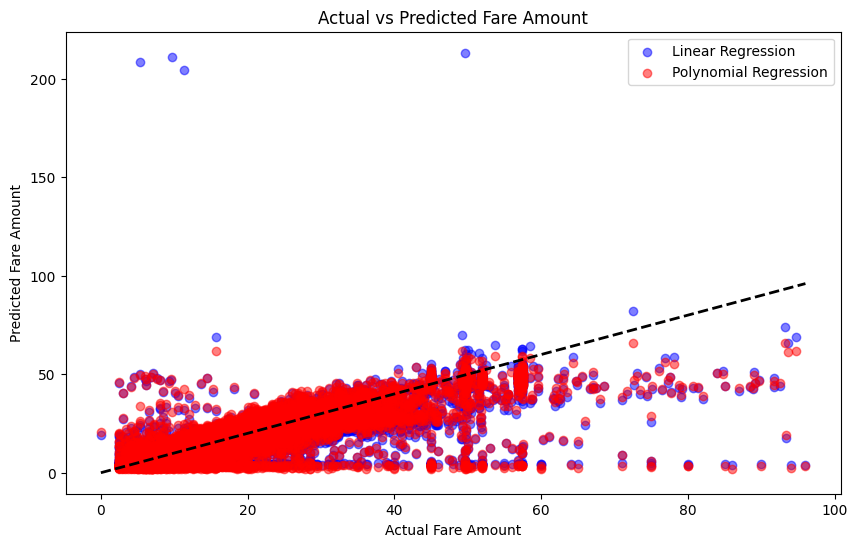

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('uber.csv')

def prepare_input(distance, hour, day_of_week, month, is_weekend, passenger_count):
    input_data = pd.DataFrame({
        'distance': [distance],
        'hour': [hour],
        'day_of_week': [day_of_week],
        'month': [month],
        'is_weekend': [is_weekend],
        'passenger_count': [passenger_count]
    })
    return input_data
    
# Data preprocessing
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data['hour'] = data['pickup_datetime'].dt.hour
data['day_of_week'] = data['pickup_datetime'].dt.dayofweek
data['month'] = data['pickup_datetime'].dt.month
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

# Haversine distance calculation
def haversine_distance(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return c * r

data['distance'] = haversine_distance(data['pickup_longitude'], data['pickup_latitude'],
                                      data['dropoff_longitude'], data['dropoff_latitude'])

# Remove outliers
data = data[(data['fare_amount'] > 0) & (data['fare_amount'] < 100) & 
            (data['distance'] < 100) & (data['passenger_count'] <= 6)]

# Feature selection
features = ['distance', 'hour', 'day_of_week', 'month', 'is_weekend', 'passenger_count']
X = data[features]
y = data['fare_amount']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create pipelines
lr_pipeline = make_pipeline(SimpleImputer(strategy='mean'),
                            StandardScaler(),
                            LinearRegression())

poly_pipeline = make_pipeline(SimpleImputer(strategy='mean'),
                              StandardScaler(),
                              PolynomialFeatures(degree=2),
                              Ridge(alpha=1.0))

# Fit models
lr_pipeline.fit(X_train, y_train)
poly_pipeline.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_pipeline.predict(X_test)
poly_predictions = poly_pipeline.predict(X_test)

# Evaluate models
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Results:")
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared Score: {r2}")
    print(f"Root Mean Squared Error: {np.sqrt(mse)}")
    print()

evaluate_model(y_test, lr_predictions, "Linear Regression")
evaluate_model(y_test, poly_predictions, "Polynomial Regression")

# Cross-validation
lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
poly_cv_scores = cross_val_score(poly_pipeline, X, y, cv=5, scoring='neg_mean_squared_error')

print("Cross-validation Results:")
print(f"Linear Regression RMSE: {np.sqrt(-lr_cv_scores.mean())}")
print(f"Polynomial Regression RMSE: {np.sqrt(-poly_cv_scores.mean())}")


def predict_fare(poly_pipeline, distance, hour, day_of_week, month, is_weekend, passenger_count):
    input_data = prepare_input(distance, hour, day_of_week, month, is_weekend, passenger_count)
    prediction = poly_pipeline.predict(input_data)
    return prediction[0]


# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_predictions, color='blue', alpha=0.5, label='Linear Regression')
plt.scatter(y_test, poly_predictions, color='red', alpha=0.5, label='Polynomial Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Fare Amount')
plt.ylabel('Predicted Fare Amount')
plt.title('Actual vs Predicted Fare Amount')
plt.legend()
plt.show()